In [56]:
#Videodaki sırayı izleyerek Neuron, Layer ve MLP sınıflarını kur. Parametreleri tek listede topla, videodaki küçük veri setiyle eğit, loss'un adım adım düştüğünü göster. Her adımda gradient'leri sıfırlamayı unutma, videodaki meşhur bug. (1:43:55 - 2:14:03)

In [119]:
import math
import random

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data   
        self.grad = 0.0    
        self._backward = lambda: None 
        self._prev = set(_children) 
        self._op = _op 
        self.label = label 

    def __repr__(self): 
        out = f"Value(data={self.data})"  
        return out 
    
    def __add__(self, other):  
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+') 
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    def __radd__(self, other):
        
        return self + other
    
    def __mul__(self, other): 
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data * other.data, (self, other), '*') 

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    def __pow__ (self, other): 
        assert isinstance(other, (int, float)), ' supporting int/float' 
        out = Value(self.data**other,(self,),f'**{other}')   

        def _backward():
            self.grad += other * (self.data ** (other - 1 )) * out.grad 
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other): 
        return self * other ** -1
     
    def __neg__(self):      
        return self * -1

    def __sub__(self,other): 
        return self + (-other)
    

    def tanh(self):   
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp (self): 
        x = self. data
        out = Value(math. exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out 
    
    def backward (self): 
        topo = [] 
        visited = set () 
        def build_topo(v): 
            if v not in visited:  
                visited.add(v) 
                for child in v._prev: build_topo(child) 
                topo.append(v) 
        build_topo(self) 
        self.grad = 1.0  
        for node in reversed (topo): 
            node._backward()


In [120]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record') 
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [121]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x )), self.b )
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
    

class Layer:
    def __init__(self, nin ,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
       return [param for neuron in self.neurons for param in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i] , sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()] 

    

In [122]:
n = Neuron(2)      # 2 girişli tek bir nöron
x = [1.0, -2.0]    # girdi değerleri
n(x)        

Value(data=0.388711395578055)

In [123]:
x = [2.0, 3.0] # 2 girişli 
n = Layer(2,3) 
n(x)

[Value(data=0.97366603056074),
 Value(data=0.07014294297878414),
 Value(data=0.9756282345178121)]

In [124]:
x = [2.0, 3.0,-1.0]
n = MLP(3,[4, 4, 1])
n(x) 

Value(data=0.102920344191683)

In [125]:
x = [2.0, 3.0,-1.0]
n = MLP(3,[4, 4, 1])
out = n(x)
print(n.parameters()[:5])
print(len(n.parameters())) # networkun 41 tane parametresi var. 

[Value(data=-0.5862680334743591), Value(data=-0.3055989658647027), Value(data=0.474555685310887), Value(data=0.9871889850404494), Value(data=-0.4415436316128145)]
41


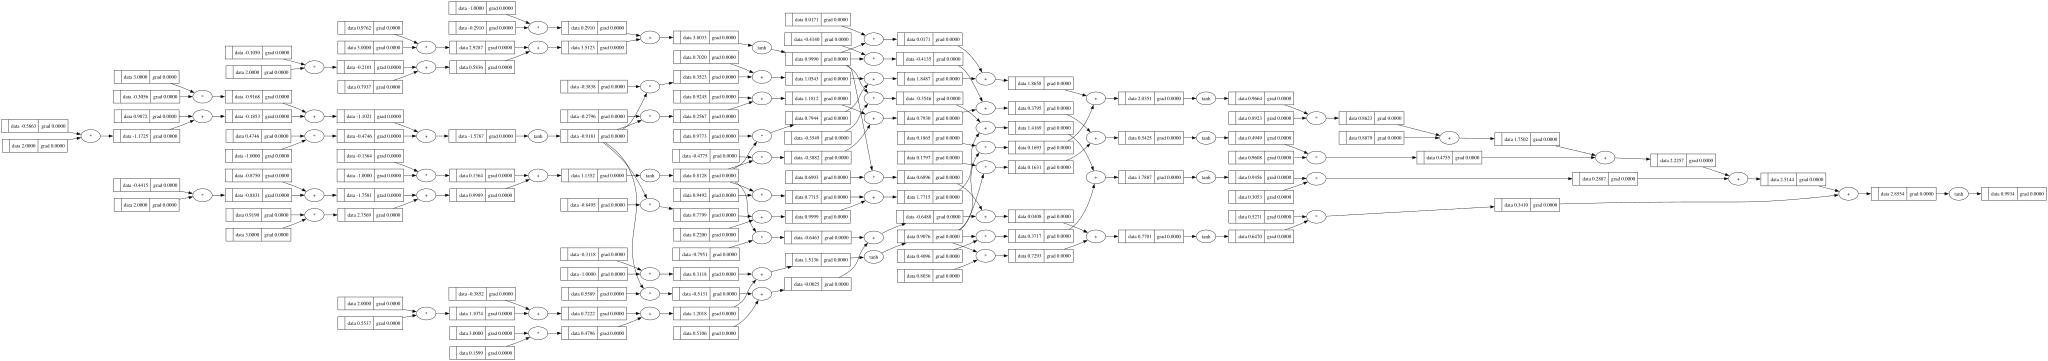

In [126]:
draw_dot(n(x))

In [127]:
xs = [ [2.0, 3.0 , -1.0],
       [3.0, -1.0, 0.5],
       [0.5, 1.0, 1.0],
       [1.0,1.0,-1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9934020732160246),
 Value(data=0.9760416072929882),
 Value(data=0.9266804147160937),
 Value(data=0.9898745595194058)]

In [128]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=4.353263784670018e-05),
 Value(data=3.9047404337530565),
 Value(data=3.7120974204505788),
 Value(data=0.00010252454492605492)]

In [129]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.6169839113864075)

In [130]:
loss.backward()

In [131]:
print(n.layers[0].neurons[0].w[0])
print(n.layers[0].neurons[0].w[0].grad) # grad negatif yani lossa etkisi de negatif yani biz bu w yi yükselltiğimizde h kadar, loss düşecek demek w yi arttır.

Value(data=-0.5862680334743591)
-0.38334907900892046


In [132]:
xs = [ [2.0, 3.0 , -1.0],
       [3.0, -1.0, 0.5],
       [0.5, 1.0, 1.0],
       [1.0,1.0,-1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9934020732160246),
 Value(data=0.9760416072929882),
 Value(data=0.9266804147160937),
 Value(data=0.9898745595194058)]

In [173]:
ypred = [n(x) for x in xs] 
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

for p in n.parameters():
    p.grad = 0.0  

loss.backward()

for p in n.parameters():   
    p.data += -0.01 * p.grad

print(loss)

Value(data=0.816105165659762)


In [174]:
ypred #[1.0, -1.0, -1.0, 1.0]

[Value(data=0.9850648113036083),
 Value(data=-0.21906733716746707),
 Value(data=-0.694490445707055),
 Value(data=0.6643063983997003)]

In [ ]:
# 1. loss: 3.8515689081767057
# birkaç çalıştırmadan sonra loss: 0.9355684073472185

In [175]:
for k in range(40):
    ypred = [n(x) for x in xs] 
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0  

    loss.backward()

    for p in n.parameters():   
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.6642550469811116
1 0.24805905717596588
2 0.1452272975137916
3 0.10254855142403567
4 0.07902537038115934
5 0.0641880989588851
6 0.05400136364260015
7 0.0465865520352719
8 0.040953545324463325
9 0.036532074559366724
10 0.03297098351155517
11 0.03004244186211774
12 0.027592291485655576
13 0.025512558381341813
14 0.02372539854936353
15 0.022173295080221173
16 0.020812842945810452
17 0.019610679424588356
18 0.018540743979503907
19 0.017582387628521285
20 0.016719039990573517
21 0.015937251296035196
22 0.015225991945818473
23 0.014576132387925591
24 0.01398005143845902
25 0.013431337541104454
26 0.012924558240864187
27 0.012455080383515308
28 0.012018928491354858
29 0.011612672190166554
30 0.011233335970857686
31 0.010878326285845267
32 0.010545372218907185
33 0.010232476871225879
34 0.009937877273205442
35 0.009660011128470905
36 0.009397489070080051
37 0.009149071392413548
38 0.008913648439001606
39 0.008690223993654739


In [176]:
ypred

[Value(data=0.992088572815799),
 Value(data=-0.9379646138528387),
 Value(data=-0.950852449848542),
 Value(data=0.9513814593673737)]